# Quora Duplicate Detection – Results

Loads pre-trained models and evaluates them on the test split. No training here.  
Expected execution time: < 2 minutes.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve,
)
from utils import extract_simple_features, extract_improved_features, get_mistakes

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

## 1. Load Test Data and Models

In [2]:
test_df = pd.read_csv('test_df.csv')
y_test  = test_df['is_duplicate'].values
print('Test set shape:', test_df.shape)
print(f'Duplicate rate: {y_test.mean():.1%}  ({y_test.sum()} duplicates / {len(y_test)} total)')

Test set shape: (16172, 6)
Duplicate rate: 37.1%  (6007 duplicates / 16172 total)


In [3]:
MODELS_DIR = 'models'
tfidf_simple = joblib.load(os.path.join(MODELS_DIR, 'tfidf_simple.joblib'))
simple_lr    = joblib.load(os.path.join(MODELS_DIR, 'simple_lr.joblib'))
tfidf_word   = joblib.load(os.path.join(MODELS_DIR, 'tfidf_word.joblib'))
tfidf_char   = joblib.load(os.path.join(MODELS_DIR, 'tfidf_char.joblib'))
improved_gbm = joblib.load(os.path.join(MODELS_DIR, 'improved_gbm.joblib'))
print('All models loaded.')

All models loaded.


## 2. Generate Predictions

In [4]:
X_test_simple = extract_simple_features(test_df, tfidf_simple)
y_prob_s = simple_lr.predict_proba(X_test_simple)[:, 1]
y_pred_s = simple_lr.predict(X_test_simple)

print('Extracting improved features...')
X_test_imp = extract_improved_features(test_df, tfidf_word, tfidf_char)
y_prob_i = improved_gbm.predict_proba(X_test_imp)[:, 1]
y_pred_i = improved_gbm.predict(X_test_imp)
print('Done.')

Extracting improved features...


Done.


## 3. Metrics Table

In [5]:
def metrics(y_true, y_prob, y_pred):
    return dict(
        ROC_AUC   = round(roc_auc_score(y_true, y_prob),  4),
        Precision = round(precision_score(y_true, y_pred), 4),
        Recall    = round(recall_score(y_true, y_pred),    4),
        F1        = round(f1_score(y_true, y_pred),        4),
    )

results = pd.DataFrame([
    {'Model': 'Simple  (TF-IDF cosine + LR)',    **metrics(y_test, y_prob_s, y_pred_s)},
    {'Model': 'Improved (18 features + HistGBM)', **metrics(y_test, y_prob_i, y_pred_i)},
]).set_index('Model')

results

,ROC_AUC,Precision,Recall,F1
Model,,,,
Simple (TF-IDF cosine + LR),0.6775,0.4803,0.2477,0.3269
Improved (18 features + HistGBM),0.8546,0.6701,0.7291,0.6984


## 4. ROC Curves

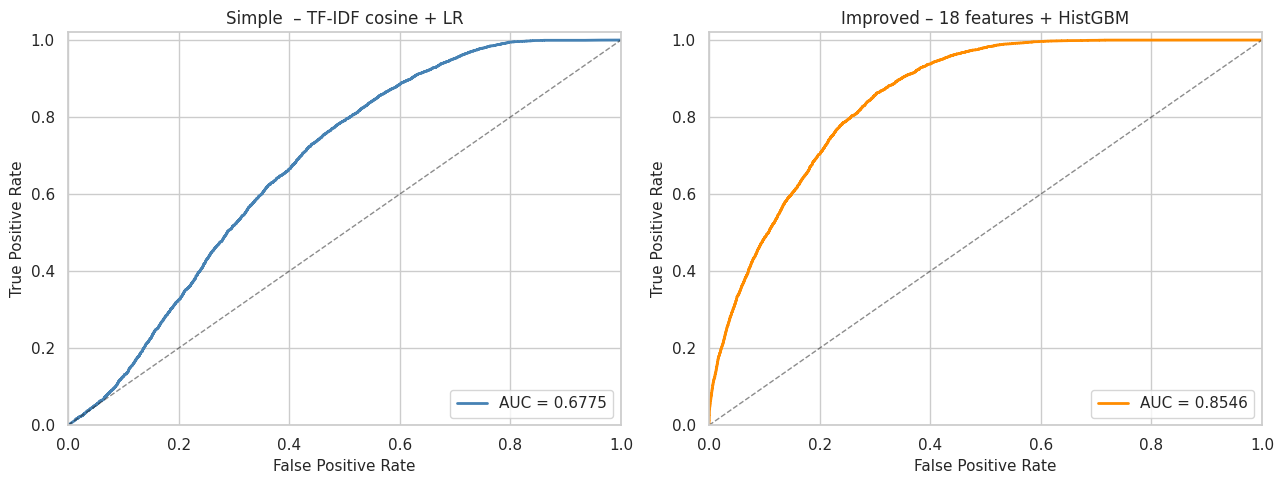

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_prob, y_pred, color) in zip(axes, [
    ('Simple  – TF-IDF cosine + LR',    y_prob_s, y_pred_s, 'steelblue'),
    ('Improved – 18 features + HistGBM', y_prob_i, y_pred_i, 'darkorange'),
]):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend(loc='lower right', fontsize=11)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrices

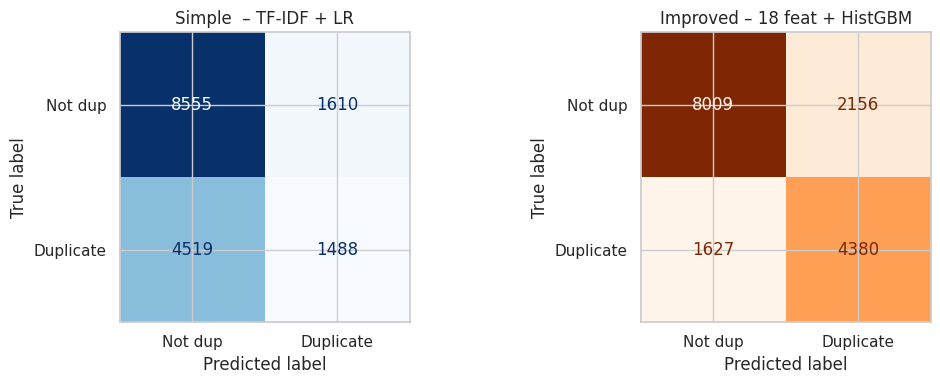

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, y_pred, cmap) in zip(axes, [
    ('Simple  – TF-IDF + LR',        y_pred_s, 'Blues'),
    ('Improved – 18 feat + HistGBM',  y_pred_i, 'Oranges'),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not dup', 'Duplicate'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name, fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Precision–Recall Curves

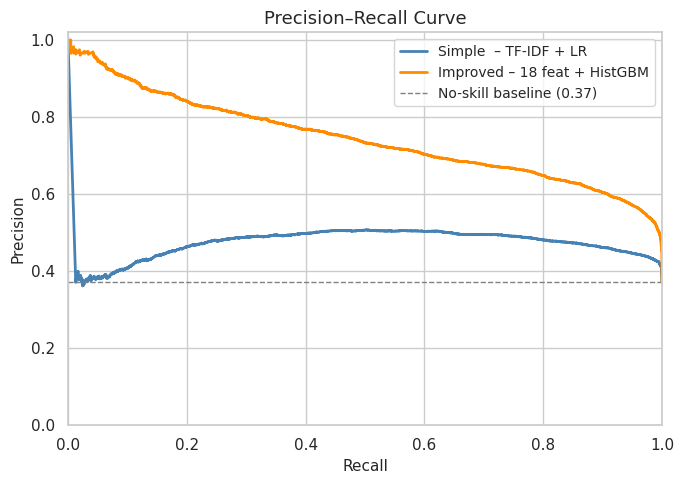

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, y_prob, color in [
    ('Simple  – TF-IDF + LR',        y_prob_s, 'steelblue'),
    ('Improved – 18 feat + HistGBM',  y_prob_i, 'darkorange'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, lw=2, color=color, label=name)

baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', lw=1,
           label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision–Recall Curve', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Score Distributions

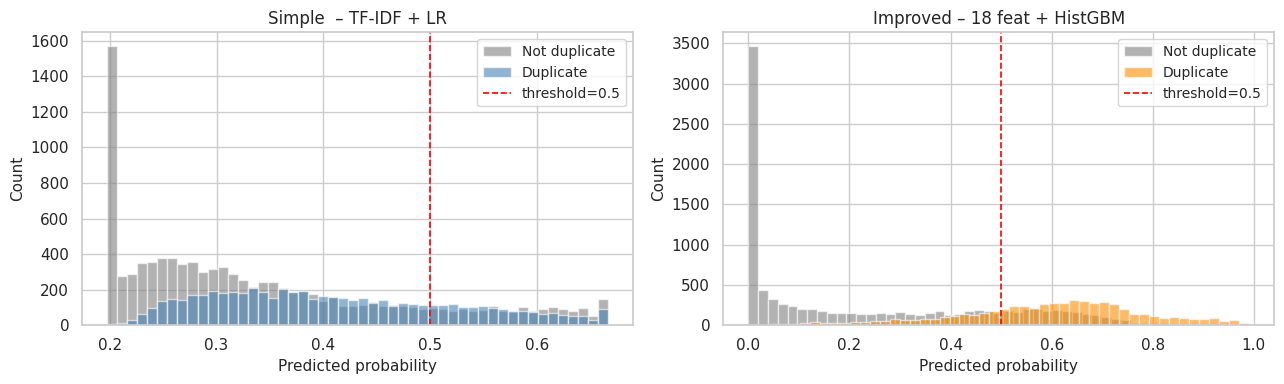

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (name, y_prob, color) in zip(axes, [
    ('Simple  – TF-IDF + LR',        y_prob_s, 'steelblue'),
    ('Improved – 18 feat + HistGBM',  y_prob_i, 'darkorange'),
]):
    ax.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label='Not duplicate', color='grey')
    ax.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label='Duplicate',     color=color)
    ax.axvline(0.5, color='red', lw=1.2, linestyle='--', label='threshold=0.5')
    ax.set_xlabel('Predicted probability', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importances (Improved Model)

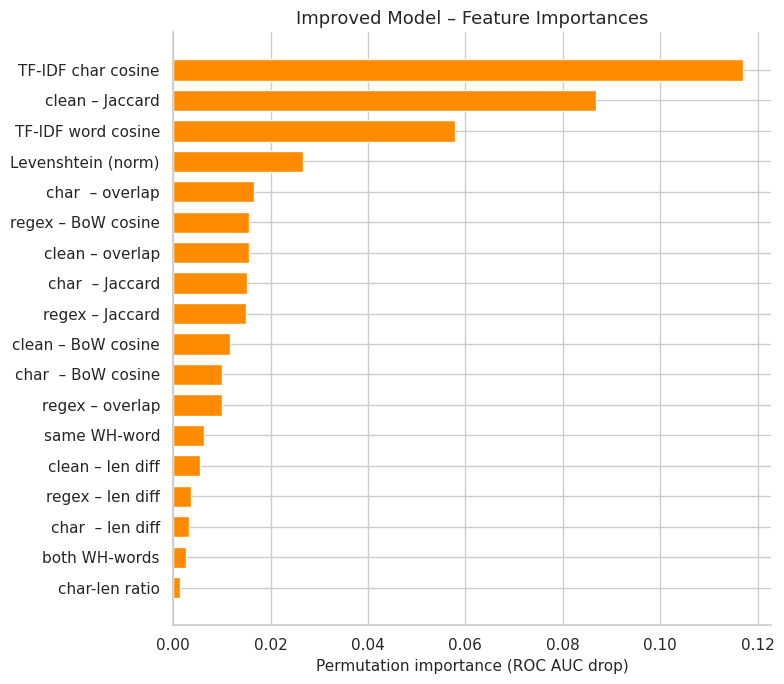

In [10]:
from sklearn.inspection import permutation_importance

feature_names = [
    'regex – Jaccard',     'regex – overlap',  'regex – BoW cosine',  'regex – len diff',
    'clean – Jaccard',     'clean – overlap',  'clean – BoW cosine',  'clean – len diff',
    'char  – Jaccard',     'char  – overlap',  'char  – BoW cosine',  'char  – len diff',
    'TF-IDF word cosine',  'TF-IDF char cosine',
    'Levenshtein (norm)',   'char-len ratio',
    'same WH-word',        'both WH-words',
]

# HistGBM has no built-in feature_importances_; use permutation importance on a 2k subset
rng = np.random.default_rng(42)
subset = rng.choice(len(y_test), size=2000, replace=False)
perm = permutation_importance(
    improved_gbm, X_test_imp[subset], y_test[subset],
    n_repeats=5, random_state=42, scoring='roc_auc',
)
importances = perm.importances_mean
order = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    [feature_names[i] for i in order],
    importances[order],
    color='darkorange', edgecolor='white', height=0.7,
)
ax.set_xlabel('Permutation importance (ROC AUC drop)', fontsize=11)
ax.set_title('Improved Model – Feature Importances', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Sample Errors

In [11]:
wrong_idx, all_preds = get_mistakes(improved_gbm, X_test_imp, y_test)

sample = test_df.iloc[wrong_idx[:8]][['question1', 'question2', 'is_duplicate']].copy()
sample['predicted'] = all_preds[wrong_idx[:8]]
sample['error_type'] = sample.apply(
    lambda r: 'False Positive' if r['predicted'] == 1 else 'False Negative', axis=1)
sample.reset_index(drop=True, inplace=True)

print(f'Total errors: {len(wrong_idx)} / {len(y_test)}  '
      f'({len(wrong_idx)/len(y_test):.1%} error rate)')
sample

Total errors: 3783 / 16172  (23.4% error rate)


,question1,question2,is_duplicate,predicted,error_type
0,How good/bad will it be for India if Trump win...,If Donald Trump wins the presidential election...,1,0,False Negative
1,What parts should I upgrade on my PC?,What part should I upgrade on my PC?,0,1,False Positive
2,What are crop tops?,What is crop top?,1,0,False Negative
3,What are the top 5 headphones under Rs.1000 in...,What are the best headphones under Rs. 2000 in...,0,1,False Positive
4,Why do Twitter accounts get suspended?,How do I get my suspended Twitter account rein...,0,1,False Positive
5,What is Sagittarius B?,What does Sagittarius mean?,0,1,False Positive
6,How can I hack whatsapp?,How do I hack WhatsApp online?,1,0,False Negative
7,How can I pass a drug test for meth in two days?,Is there anything you can take to pass a urine...,1,0,False Negative
